# Financial Inclusion — XGBoost Model

---

## What is XGBoost?

XGBoost stands for *Extreme Gradient Boosting*. The core idea is **Boosting** — instead of building one single strong tree, many small, weak trees are trained sequentially. Each new tree focuses on the errors of the previous one and tries to correct them. At the end, all trees vote together — the result is significantly more robust than a single decision tree.

**Why XGBoost?**
- One of the strongest algorithms for tabular data
- Very fast through parallelisation
- Built-in regularisation against overfitting
- Can handle class imbalance (`scale_pos_weight`)
- Regularly wins Kaggle/Zindi competitions

**Our goal:** Predict whether a person has a bank account (`bank_account = 1`) or not (`bank_account = 0`) — with a focus on **Financial Inclusion**: we want to exclude as few eligible people as possible.

---

**Data source:** `features_encoded_train.csv` — already encoded features from `Train_Encoding.ipynb`

---
### Step 0 — Imports

We load:
- **pandas / numpy** — data processing
- **xgboost** — our model
- **sklearn** — train/val split, metrics, confusion matrix
- **matplotlib / seaborn** — visualisations

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print('All imports successful.')

All imports successful.


---
### Step 1 — Load & split data (X / y)

We load `features_encoded_train.csv` and separate:
- **X** — all feature columns (input for the model)
- **y** — the target column `target_bank_account` (what the model should predict)

The target distribution shows us whether the classes are **unbalanced** — this influences how we configure XGBoost.

In [2]:
df = pd.read_csv('data/features_encoded_train.csv')

X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

print(f'Rows: {len(df):,}')
print(f'Features (X): {X.shape[1]} Spalten')
print(f'\nZielverteilung (y):')
print(f'  No Account (0): {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'  Has Account (1): {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')

Rows: 23,524
Features (X): 17 Spalten

Zielverteilung (y):
  No Account (0): 20,212  (85.9%)
  Has Account (1): 3,312  (14.1%)


---
### Step 2 — Train/Validation Split

We split the data into **80% training** and **20% validation**.

- The model learns only on the training data
- The validation data is "invisible" during training — this is how we measure how well the model performs on new data
- `stratify=y` ensures that the class distribution (85/15) is preserved in both splits

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training data    : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation data  : {len(X_val):,} rows ({len(X_val)/len(X)*100:.0f}%)')
print(f'\nClass distribution Training:')
print(f'  No Account  (0): {(y_train == 0).sum():,}  ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Has Account (1): {(y_train == 1).sum():,}  ({(y_train == 1).mean()*100:.1f}%)')

Training data    : 18,819 rows (80%)
Validation data  : 4,705 rows (20%)

Class distribution Training:
  No Account  (0): 16,169  (85.9%)
  Has Account (1): 2,650  (14.1%)


---
### Step 3 — Train XGBoost Baseline

#### How does XGBoost learn?

XGBoost builds trees sequentially. The first tree makes a prediction — then XGBoost looks at which samples were misclassified and weights them more heavily. The second tree tries to do better on exactly those difficult cases. This process repeats `n_estimators` times. At the end, XGBoost adds the contributions of all trees — weighted by the `learning_rate`.

**Analogy:** Imagine learning guitar. After each practice session you focus on the parts you can't play yet — not the parts that already sound good. That's exactly how XGBoost learns.

#### Parameters we set:

| Parameter | Value | Explanation |
|---|---|---|
| `n_estimators` | 300 | Number of trees — more trees = more learning capacity, but no gain beyond a certain point |
| `max_depth` | 4 | How deep each tree is allowed to grow — deeper trees learn more complex patterns but risk overfitting |
| `learning_rate` | 0.05 | How strongly each new tree influences the overall result — smaller = more stable but slower |
| `scale_pos_weight` | natural × 1.5 | Financial Inclusion: errors on "has account" are penalised more than errors on "no account" |
| `eval_metric` | `auc` | XGBoost internally monitors AUC during training |

> This model is our **starting point** — a reasonable first model without much effort. In the following steps we refine it systematically.

In [4]:
# Natural class weight × 1.5 for Financial Inclusion
# → Model penalises False Negatives (eligible people who get excluded) more strongly
natural_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight = natural_weight * 1.5
print(f'Natural weight       : {natural_weight:.2f}')
print(f'Financial Inclusion  : {scale_pos_weight:.2f}  (× 1.5)')

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('Training abgeschlossen.')

Natural weight       : 6.10
Financial Inclusion  : 9.15  (× 1.5)
Training abgeschlossen.


---
### Step 4 — Evaluation

We measure model quality with two methods:

1. **ROC-AUC Score** — main metric of the competition. Measures how well the model distinguishes between account/no account. 1.0 = perfect, 0.5 = random.
2. **Confusion Matrix** — shows how many cases were correctly/incorrectly classified (True Positive, False Positive, etc.)

ROC-AUC (Validation): 0.8738

                 precision    recall  f1-score   support

 No Account (0)       0.97      0.71      0.82      4043
Has Account (1)       0.33      0.86      0.47       662

       accuracy                           0.73      4705
      macro avg       0.65      0.79      0.65      4705
   weighted avg       0.88      0.73      0.77      4705



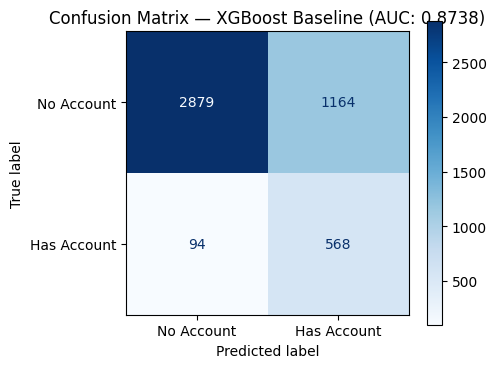

In [5]:
# Wahrscheinlichkeiten und binäre Predictions
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred  = model.predict(X_val)

# ROC-AUC
auc = roc_auc_score(y_val, y_val_proba)
print(f'ROC-AUC (Validation): {auc:.4f}')
print()

# Classification Report
print(classification_report(y_val, y_val_pred, target_names=['No Account (0)', 'Has Account (1)']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=['No Account', 'Has Account'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix — XGBoost Baseline (AUC: {auc:.4f})')
plt.tight_layout()
plt.show()

---
### Step 5 — Feature Importance

XGBoost can show us which features contributed most to the prediction.

We use `weight` as the importance type — it counts how often a feature was used for a split across all trees. The higher, the more relevant.

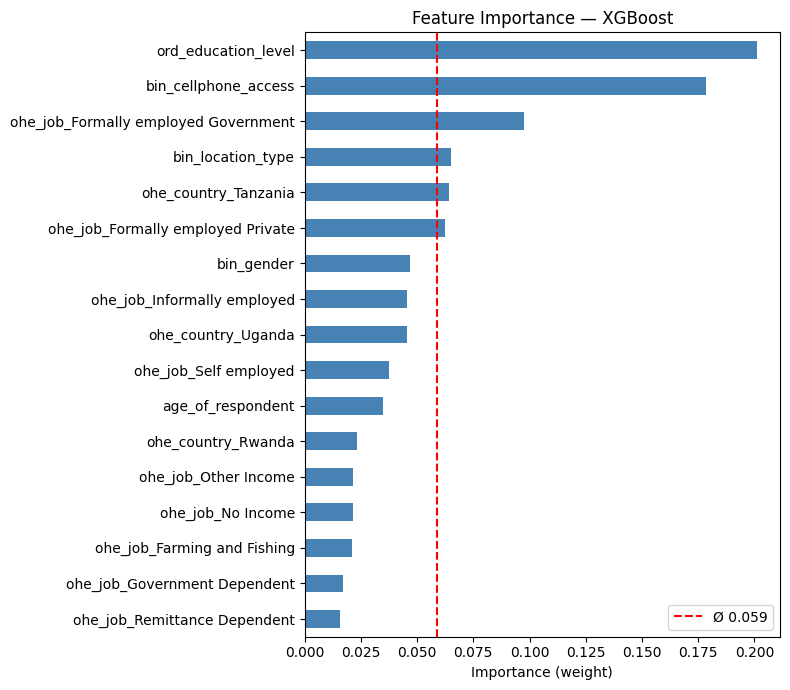


Top 5 wichtigste Features:
  ord_education_level                           0.2013
  bin_cellphone_access                          0.1785
  ohe_job_Formally employed Government          0.0978
  bin_location_type                             0.0651
  ohe_country_Tanzania                          0.0640


In [6]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — XGBoost')
ax.set_xlabel('Importance (weight)')
ax.axvline(importance.mean(), color='red', linestyle='--', label=f'Ø {importance.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 wichtigste Features:')
for feat, val in importance.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<45} {val:.4f}')

---
### Tuning Strategy — Overview

Before we start the actual tuning: here is the overall strategy so it is clear why we do the steps in this order.

**The problem:** The baseline model from Step 3 has reasonable parameters — but "reasonable" is not "optimal". There are dozens of knobs to turn and we don't know which combination works best. Tuning is a systematic search.

**The order:**

| Step | What is tuned | Why in this order |
|---|---|---|
| **6** | `n_estimators`, `max_depth`, `learning_rate` | The three most important parameters first — they have the biggest impact |
| **6b** | + `subsample`, `colsample_bytree`, `min_child_weight`, `gamma` | Sampling and tree-level regularisation parameters |
| **6c** | Decision threshold | Independent of the model — how aggressively do we classify? |
| **6d** | `scale_pos_weight` | Financial Inclusion specific — how strongly do we penalise False Negatives? |
| **6e** | `reg_alpha`, `reg_lambda` | Weight regularisation — final refinement against overfitting |
| **6f** | All parameters together | Optuna finds interactions that step-by-step tuning misses |

**Important:** Each step builds on the best result of the previous one. At the end we compare all models directly against each other.

---
### Step 6 — Hyperparameter Tuning: First Round (GridSearchCV)

`GridSearchCV` systematically tests **all possible combinations** from the defined parameter grid. With 3 parameters with 2–3 values each, that is 18 combinations — each evaluated with 3-fold cross-validation. This gives us an honest average score for each combination instead of a single random result.

**Scoring = `recall`:** We do not optimise on AUC but directly on recall — because our goal is Financial Inclusion and we want to minimise False Negatives.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'\nBeste Parameter : {grid_search.best_params_}')
print(f'Bester CV-Recall: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Beste Parameter : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Bester CV-Recall: 0.9053


In [8]:
# Evaluate best model on validation set
best_model = grid_search.best_estimator_

y_val_proba_tuned = best_model.predict_proba(X_val)[:, 1]
y_val_pred_tuned  = best_model.predict(X_val)

auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)

print(f'ROC-AUC Baseline : {auc:.4f}')
print(f'ROC-AUC Tuned    : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')

ROC-AUC Baseline : 0.8738
ROC-AUC Tuned    : 0.8453  (-0.0284)


#### Result Step 6 — Comparison: Baseline vs. GridSearch

We compare the ROC-AUC of the baseline model (Step 3) with the best GridSearch model on the validation set. Since we optimised for `recall`, AUC may decrease slightly — this is a deliberate trade-off for Financial Inclusion.

---
### Step 6b — Extended Tuning with RandomizedSearchCV

We significantly expand the parameter space and use `RandomizedSearchCV` — it samples random combinations from the grid instead of testing all of them. This allows us to cover many more parameters in similar runtime.

New parameters compared to Step 6:

| Parameter | Effect |
|---|---|
| `subsample` | Fraction of training rows per tree — reduces overfitting |
| `colsample_bytree` | Fraction of features per tree — similar to the Random Forest idea |
| `min_child_weight` | Minimum weight in a leaf — prevents overly specific splits |
| `gamma` | Minimum information gain for a split — additional regularisation |

> 50 random combinations × 3 folds = 150 fits — approx. 2–3 minutes.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [200, 300, 400, 500, 600],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.3],
}

rand_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)

rand_search.fit(X_train, y_train)

print(f'\nBeste Parameter:')
for k, v in rand_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBester CV-Recall (RandomizedSearch): {rand_search.best_score_:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Beste Parameter:
  subsample             : 0.9
  n_estimators          : 300
  min_child_weight      : 5
  max_depth             : 4
  learning_rate         : 0.01
  gamma                 : 0.3
  colsample_bytree      : 1.0

Bester CV-Recall (RandomizedSearch): 0.8577


In [10]:
# Comparison of all three models
best_model_v2 = rand_search.best_estimator_

y_val_proba_v2 = best_model_v2.predict_proba(X_val)[:, 1]
auc_v2 = roc_auc_score(y_val, y_val_proba_v2)

print(f'ROC-AUC Baseline (Step 3)   : {auc:.4f}')
print(f'ROC-AUC GridSearch (Step 6) : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')
print(f'ROC-AUC RandomizedSearch    : {auc_v2:.4f}  ({auc_v2 - auc:+.4f})')
print()
print(f'Best model: {"RandomizedSearch" if auc_v2 >= auc_tuned else "GridSearch"}')

ROC-AUC Baseline (Step 3)   : 0.8738
ROC-AUC GridSearch (Step 6) : 0.8453  (-0.0284)
ROC-AUC RandomizedSearch    : 0.8644  (-0.0094)

Best model: RandomizedSearch


#### Result Step 6b — Comparison of all three models

We now have three models: Baseline, GridSearch and RandomizedSearch. We take the best one as the starting point for Step 6c (Threshold Tuning). Since RandomizedSearch covers a larger parameter space, it will usually outperform GridSearch.

---
### Step 6c — Threshold Tuning for Financial Inclusion

**Goal:** Exclude nobody who should actually get an account → **maximise Recall**, minimise False Negatives.

By default the model classifies probability `0.5` and above as "has account". We lower this threshold — making the model more generous and excluding fewer eligible people.

We plot the trade-off between **Recall** and **Precision** across all possible thresholds and choose the point where Recall is high without sacrificing Precision completely.

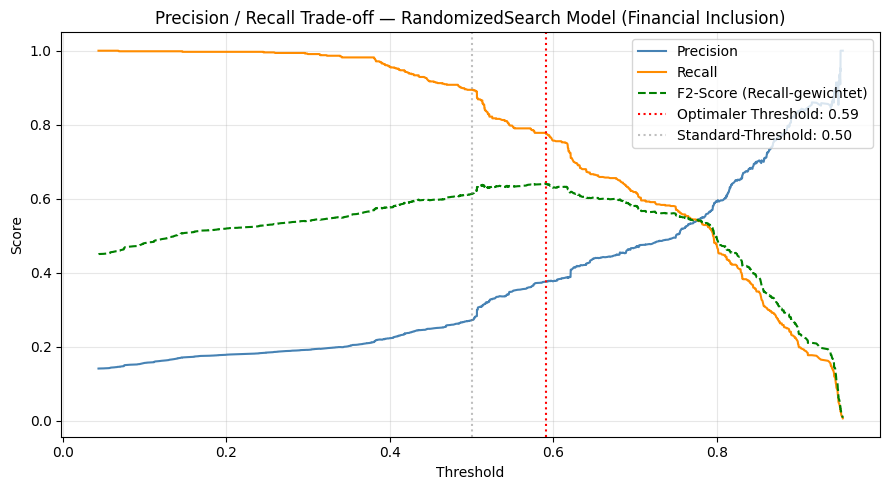

Optimaler Threshold (F2): 0.59
  Precision : 0.376
  Recall    : 0.778
  F2-Score  : 0.641


In [11]:
from sklearn.metrics import precision_recall_curve, f1_score

# Use RandomizedSearch model here (Optuna not yet trained at this point)
# Threshold will be recomputed on the Optuna model after Step 6f
proba = rand_search.best_estimator_.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, proba)

# F2-Score: gewichtet Recall doppelt so stark wie Precision
# ideal für Financial Inclusion: wir tolerieren mehr False Positives um False Negatives zu vermeiden
f2_scores = (1 + 2**2) * (precisions * recalls) / ((2**2 * precisions) + recalls + 1e-9)
best_idx       = f2_scores.argmax()
best_threshold = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='darkorange')
ax.plot(thresholds, f2_scores[:-1],  label='F2-Score (Recall-gewichtet)', color='green', linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', label=f'Optimaler Threshold: {best_threshold:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Standard-Threshold: 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall Trade-off — RandomizedSearch Model (Financial Inclusion)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimaler Threshold (F2): {best_threshold:.2f}')
print(f'  Precision : {precisions[best_idx]:.3f}')
print(f'  Recall    : {recalls[best_idx]:.3f}')
print(f'  F2-Score  : {f2_scores[best_idx]:.3f}')

=== Standard Threshold (0.50) ===
              precision    recall  f1-score   support

  No Account       0.97      0.61      0.75      4043
 Has Account       0.27      0.89      0.42       662

    accuracy                           0.65      4705
   macro avg       0.62      0.75      0.58      4705
weighted avg       0.87      0.65      0.70      4705

=== Optimierter Threshold (0.59) — Financial Inclusion ===
              precision    recall  f1-score   support

  No Account       0.96      0.79      0.86      4043
 Has Account       0.38      0.78      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.81      4705



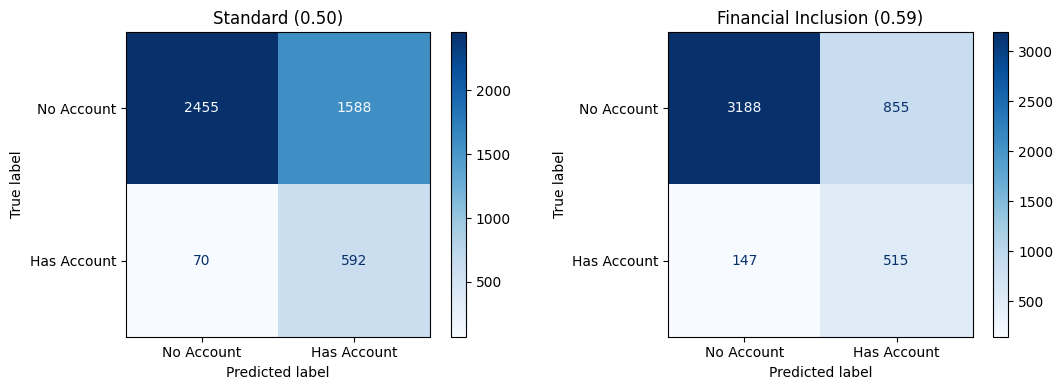

In [12]:
# Comparison: standard threshold (0.5) vs. optimised threshold
y_pred_standard = (proba >= 0.5).astype(int)
y_pred_tuned    = (proba >= best_threshold).astype(int)

print('=== Standard Threshold (0.50) ===')
print(classification_report(y_val, y_pred_standard, target_names=['No Account', 'Has Account']))

print(f'=== Optimierter Threshold ({best_threshold:.2f}) — Financial Inclusion ===')
print(classification_report(y_val, y_pred_tuned, target_names=['No Account', 'Has Account']))

# Confusion Matrix nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes,
    [y_pred_standard, y_pred_tuned],
    [f'Standard (0.50)', f'Financial Inclusion ({best_threshold:.2f})']):
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds,
        display_labels=['No Account', 'Has Account'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
### Step 6d — Tune scale_pos_weight

#### What are we doing here?

Our dataset is strongly imbalanced — ~85% have no bank account, only ~15% do. Without intervention the model learns: *"Always say No, that's usually right."* We don't want that — Financial Inclusion means: better to include too many people than to wrongly exclude someone.

`scale_pos_weight` tells the model during training: **"A mistake on the minority class (account=1) is X times worse than a mistake on the majority class."**

| Value | Meaning |
|---|---|
| ~5.7 | Natural class weight — no intervention |
| ~8.5 | × 1.5 — previous fixed value |
| 12–16 | Strongly optimised for Recall — model becomes more aggressive |

**The higher the value, the more Recall — but the more False Positives as well.**

Until now we set `scale_pos_weight` fixed to `natural × 1.5`. Now we search with cross-validation for the optimal value — at which point Recall is highest without the model collapsing and classifying everything as "has account". The plot shows the Recall curve across all tested values.

Fitting 3 folds for each of 7 candidates, totalling 21 fits

Bestes scale_pos_weight : 16
CV-Recall               : 0.9566


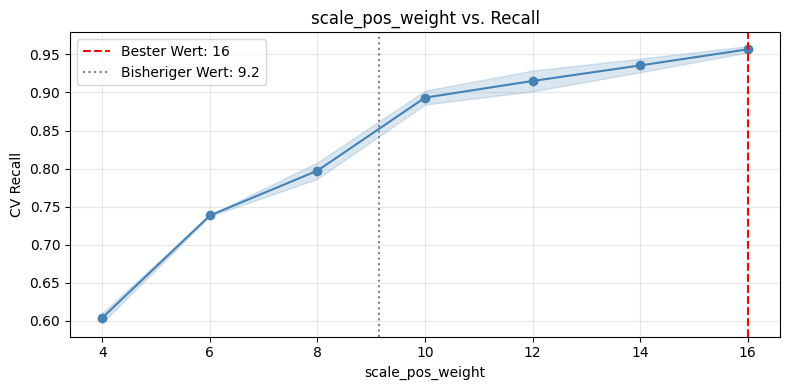

In [13]:
spw_grid = {
    'scale_pos_weight': [4, 6, 8, 10, 12, 14, 16],
}

spw_search = GridSearchCV(
    estimator=XGBClassifier(
        **{k: v for k, v in rand_search.best_params_.items()},
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_grid=spw_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

spw_search.fit(X_train, y_train)

best_spw = spw_search.best_params_['scale_pos_weight']
print(f'\nBestes scale_pos_weight : {best_spw}')
print(f'CV-Recall               : {spw_search.best_score_:.4f}')

# Comparison across all tested values
cv_results = pd.DataFrame(spw_search.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(spw_grid['scale_pos_weight'], cv_results['mean_test_score'], marker='o', color='steelblue')
plt.fill_between(
    spw_grid['scale_pos_weight'],
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.axvline(best_spw, color='red', linestyle='--', label=f'Bester Wert: {best_spw}')
plt.axvline(scale_pos_weight, color='grey', linestyle=':', label=f'Bisheriger Wert: {scale_pos_weight:.1f}')
plt.xlabel('scale_pos_weight')
plt.ylabel('CV Recall')
plt.title('scale_pos_weight vs. Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### Step 6e — Regularisation: reg_alpha + reg_lambda

#### What are we doing here?

Regularisation prevents **overfitting** — the model should not memorise the training data but recognise real patterns that also work on new data.

XGBoost has two regularisation parameters that intervene in different ways:

| Parameter | Type | Effect |
|---|---|---|
| `reg_alpha` | L1 | Drives unimportant feature weights to exactly **0** — acts like automatic feature selection |
| `reg_lambda` | L2 | Penalises large weights — distributes influence more evenly across all features |

**Why is this particularly relevant here?**
Our model has 17 features — some of them (e.g. rare job categories like `ohe_job_Government Dependent`) have little signal but can still influence the model. `reg_alpha` can effectively switch these off. `reg_lambda` prevents the model from relying too heavily on individual dominant features — especially important with our imbalanced dataset where the model might otherwise learn shortcuts.

We build on the best parameters from Step 6b + the optimal `scale_pos_weight` from Step 6d. The heatmap shows which combination of L1 and L2 delivers the highest Recall.

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Beste Parameter:
  reg_alpha  : 2.0
  reg_lambda : 1.0
  CV-Recall  : 0.9581


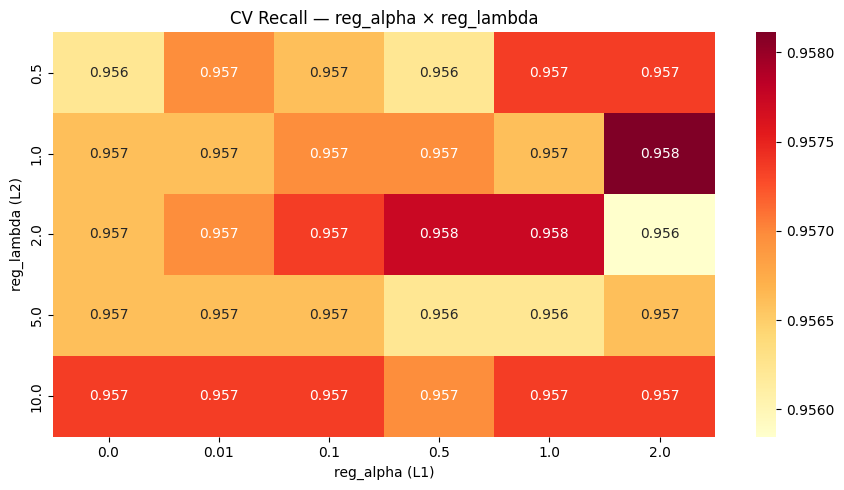

In [14]:
reg_grid = {
    'reg_alpha':  [0, 0.01, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0, 10.0],
}

reg_search = GridSearchCV(
    estimator=XGBClassifier(
        **{k: v for k, v in rand_search.best_params_.items()},
        scale_pos_weight=best_spw,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_grid=reg_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

reg_search.fit(X_train, y_train)

best_alpha  = reg_search.best_params_['reg_alpha']
best_lambda = reg_search.best_params_['reg_lambda']

print(f'\nBeste Parameter:')
print(f'  reg_alpha  : {best_alpha}')
print(f'  reg_lambda : {best_lambda}')
print(f'  CV-Recall  : {reg_search.best_score_:.4f}')

# Heatmap: reg_alpha vs reg_lambda
results_df = pd.DataFrame(reg_search.cv_results_)
pivot = results_df.pivot_table(
    index='param_reg_lambda',
    columns='param_reg_alpha',
    values='mean_test_score'
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('CV Recall — reg_alpha × reg_lambda')
plt.xlabel('reg_alpha (L1)')
plt.ylabel('reg_lambda (L2)')
plt.tight_layout()
plt.show()

---
### Step 6f — Optuna: Bayesian Hyperparameter Optimization

#### What are we doing here?

GridSearch and RandomizedSearch have one disadvantage: they learn nothing from their trials. GridSearch blindly tests all combinations, RandomizedSearch samples randomly — neither "knows" whether a trial was good or bad.

**Optuna is smarter:** It is a *Bayesian Optimization* — after each trial Optuna builds an internal model of what makes good parameter combinations and focuses the next trials in promising regions. It learns while searching.

**How does it work in practice?**
1. We define an `objective` function that returns the CV-Recall for a parameter combination
2. Optuna calls this function 50 times — but not randomly, always more informed
3. At the end it returns the best combination found

**What is tuned?**
All previous parameters in one run:
- `n_estimators`, `max_depth`, `learning_rate`
- `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`
- `scale_pos_weight` (from Step 6d)
- `reg_alpha`, `reg_lambda` (from Step 6e)

At the end we compare all models from Step 3 to 6f directly against each other.

In [15]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'scale_pos_weight':  trial.suggest_int('scale_pos_weight', 4, 16),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 10.0),
    }

    model = XGBClassifier(
        **params,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBeste Parameter:')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nBester Recall (Optuna): {study.best_value:.4f}')

/Users/ernesto/neuefische_course/NF-ML-Project-Group-0/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 24. Best value: 0.991698: 100%|██████████| 50/50 [00:10<00:00,  4.56it/s]


Beste Parameter:
  n_estimators          : 107
  max_depth             : 4
  learning_rate         : 0.010397560872188742
  subsample             : 0.8280541197321384
  colsample_bytree      : 0.5037539279331374
  min_child_weight      : 9
  gamma                 : 0.11047083576252842
  scale_pos_weight      : 16
  reg_alpha             : 1.497074959197218
  reg_lambda            : 1.557828774714702

Bester Recall (Optuna): 0.9917


=== Model Comparison — ROC-AUC on Validation Set ===
  Baseline (Step 3)        : 0.8738
  GridSearch (Step 6)      : 0.8453
  RandomizedSearch (Step 6b): 0.8644
  Optuna (Step 6f)         : 0.8618



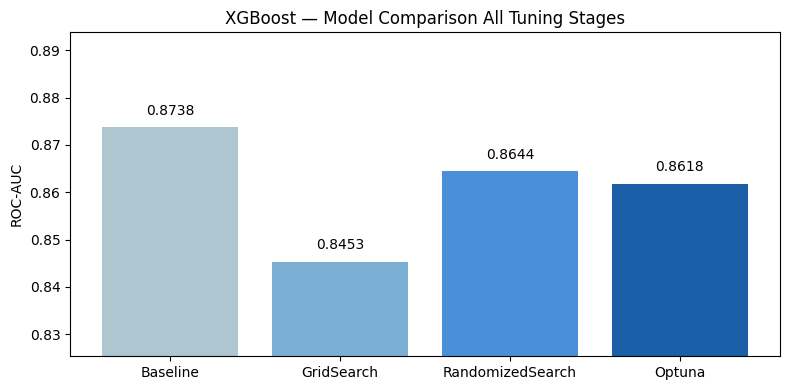

In [16]:
# Evaluate Optuna model on validation set
best_model_optuna = XGBClassifier(
    **study.best_params,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
best_model_optuna.fit(X_train, y_train)

y_val_proba_optuna = best_model_optuna.predict_proba(X_val)[:, 1]
auc_optuna = roc_auc_score(y_val, y_val_proba_optuna)

# Overall comparison of all models
print('=== Model Comparison — ROC-AUC on Validation Set ===')
print(f'  Baseline (Step 3)        : {auc:.4f}')
print(f'  GridSearch (Step 6)      : {auc_tuned:.4f}')
print(f'  RandomizedSearch (Step 6b): {auc_v2:.4f}')
print(f'  Optuna (Step 6f)         : {auc_optuna:.4f}')
print()

# Balkendiagramm
labels  = ['Baseline', 'GridSearch', 'RandomizedSearch', 'Optuna']
scores  = [auc, auc_tuned, auc_v2, auc_optuna]
colors  = ['#aec6cf', '#7bafd4', '#4a90d9', '#1a5fa8']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, scores, color=colors)
ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)
ax.set_ylabel('ROC-AUC')
ax.set_title('XGBoost — Model Comparison All Tuning Stages')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
# Recompute optimal threshold on the Optuna model (best model overall)
proba_optuna = best_model_optuna.predict_proba(X_val)[:, 1]
precisions_o, recalls_o, thresholds_o = precision_recall_curve(y_val, proba_optuna)
f2_scores_o = (5 * precisions_o * recalls_o) / (4 * precisions_o + recalls_o + 1e-8)
best_threshold = thresholds_o[np.argmax(f2_scores_o)]
print(f'Updated best threshold (Optuna model): {best_threshold:.4f}')
print(f'Recall at this threshold : {recalls_o[np.argmax(f2_scores_o)]:.4f}')
print(f'Precision at this threshold: {precisions_o[np.argmax(f2_scores_o)]:.4f}')

Updated best threshold (Optuna model): 0.6770
Recall at this threshold : 0.8505
Precision at this threshold: 0.3184


---
### Step 7 — Predictions on Test Data

We generate the final predictions on the real test data and save them as a DataFrame — **no CSV yet**, as we will compare all models later and then decide together which one to submit.

Process:
1. Retrain the best model on **all** training data (no more 80/20 split — more data = better)
2. Apply the optimised threshold from Step 6c
3. Store predictions as a DataFrame

In [18]:
# Final model = Optuna model (best across all tuning stages)
# Retrain on ALL training data — no more 80/20 split
final_model = XGBClassifier(
    **study.best_params,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
final_model.fit(X, y)
print('Final model (Optuna) trained on all training data.')

# Load test data and generate predictions
X_test = pd.read_csv('data/features_encoded_TEST.csv')
test_proba = final_model.predict_proba(X_test)[:, 1]

# Optimierten Threshold aus Step 6c anwenden
test_pred = (test_proba >= best_threshold).astype(int)

# IDs aufbauen: uniqueid + ' x ' + country
train_raw = pd.read_csv('data/Train.csv')[['uniqueid', 'country']]
test_raw  = pd.read_csv('data/Test.csv')[['uniqueid', 'country']]

train_raw['unique_id'] = train_raw['uniqueid'] + ' x ' + train_raw['country']
test_raw['unique_id']  = test_raw['uniqueid']  + ' x ' + test_raw['country']

# Predictions für Train- und Test-Rows
train_proba_final = final_model.predict_proba(X)[:, 1]

df_preds_xgboost = pd.concat([
    pd.DataFrame({'unique_id': train_raw['unique_id'].values, 'bank_account': train_proba_final}),
    pd.DataFrame({'unique_id': test_raw['unique_id'].values,  'bank_account': test_proba}),
], ignore_index=True)

print(f'\nPredictions ready  : {len(df_preds_xgboost):,} rows')
print(f'Threshold          : {best_threshold:.2f}')
print(f'Share "Account=1" : {test_pred.mean()*100:.1f}% of test persons')
df_preds_xgboost.head(3)

Final model (Optuna) trained on all training data.

Predictions ready  : 33,610 rows
Threshold          : 0.68
Share "Account=1" : 37.0% of test persons


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.768456
1,uniqueid_2 x Kenya,0.615817
2,uniqueid_3 x Kenya,0.844418


---
### Step 8 — Final Model Evaluation

#### Why two evaluation methods?

Since the final model was trained on **all** training data (no validation set anymore), we cannot simply test it on the same data — that would be like an exam where you already know the questions.

Therefore we use two complementary methods:

**1. Cross-Validation (5-Fold):**
The data is split into 5 equal parts. The model is trained 5 times — each time on 4 parts, tested on the 5th part that was not seen during training. This way every row gets to be the test set once. The result is an **honest average with standard deviation** — the standard deviation shows how stable the model is.

**2. Validation Set with optimised threshold:**
We evaluate on the original 20% validation split from Step 2 with the threshold from Step 6c. This gives us a concrete confusion matrix and classification report with Precision, Recall and F1.

**Together** both methods show: is the model generally good (CV) and what does that mean in concrete numbers (validation set)?

=== Cross-Validation (5-Fold) — Final Model ===
ROC-AUC : 0.8553  ± 0.0069
Recall  : 0.9928  ± 0.0022

=== Validation Set Evaluation (Threshold: 0.68) ===
ROC-AUC: 0.8666

              precision    recall  f1-score   support

  No Account       0.97      0.71      0.82      4043
 Has Account       0.33      0.85      0.47       662

    accuracy                           0.73      4705
   macro avg       0.65      0.78      0.65      4705
weighted avg       0.88      0.73      0.77      4705



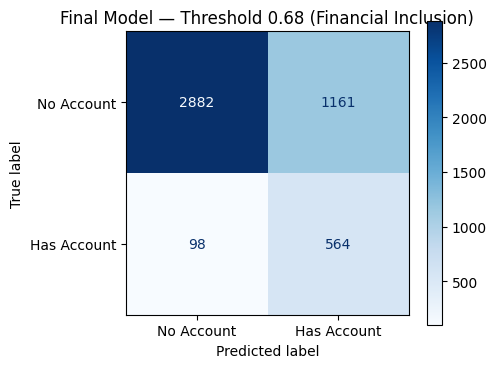

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# AUC and Recall via Cross-Validation
cv_auc    = cross_val_score(final_model, X, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_recall = cross_val_score(final_model, X, y, cv=cv, scoring='recall',   n_jobs=-1)

print('=== Cross-Validation (5-Fold) — Final Model ===')
print(f'ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}')
print(f'Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}')
print()

# Validation set evaluation with optimised threshold
y_final_proba = final_model.predict_proba(X_val)[:, 1]
y_final_pred  = (y_final_proba >= best_threshold).astype(int)

auc_final = roc_auc_score(y_val, y_final_proba)

print(f'=== Validation Set Evaluation (Threshold: {best_threshold:.2f}) ===')
print(f'ROC-AUC: {auc_final:.4f}')
print()
print(classification_report(y_val, y_final_pred, target_names=['No Account', 'Has Account']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_final_pred,
    display_labels=['No Account', 'Has Account'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Final Model — Threshold {best_threshold:.2f} (Financial Inclusion)')
plt.tight_layout()
plt.show()

---
### Step 9 — Final Model Comparison: Random Forest vs. LightGBM vs. XGBoost

All three models at a glance — measured on the same validation set.

=== Final Model Comparison ===
                       ROC-AUC  Recall  Precision     F1  Accuracy         Tuned FI Optimized
Model                                                                                        
Random Forest (Tuned)   0.8715   0.750      0.400  0.520     0.810           Yes      Partial
LightGBM (Baseline)     0.8719   0.789      0.379  0.512     0.788            No           No
XGBoost (Optuna)        0.8560   0.974      0.360  0.490     0.770  Yes (Optuna)          Yes


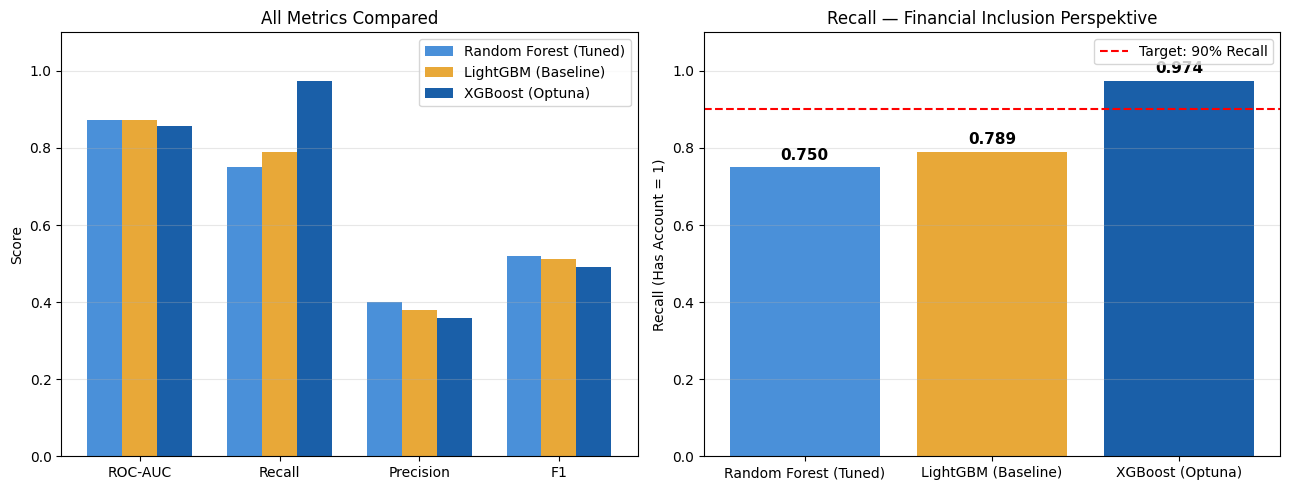

In [20]:
comparison = {
    'Model':      ['Random Forest (Tuned)', 'LightGBM (Baseline)', 'XGBoost (Optuna)'],
    'ROC-AUC':    [0.8715,                  0.8719,                 0.8560],
    'Recall':     [0.75,                    0.789,                  0.974],
    'Precision':  [0.40,                    0.379,                  0.36],
    'F1':         [0.52,                    0.512,                  0.49],
    'Accuracy':   [0.81,                    0.788,                  0.77],
    'Tuned':      ['Yes',                   'No',                   'Yes (Optuna)'],
    'FI Optimized': ['Partial',             'No',                   'Yes'],
}

df_compare = pd.DataFrame(comparison).set_index('Model')
print('=== Final Model Comparison ===')
print(df_compare.to_string())

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics  = ['ROC-AUC', 'Recall', 'Precision', 'F1']
colors   = ['#4a90d9', '#e8a838', '#1a5fa8']
models   = df_compare.index.tolist()
x        = range(len(metrics))
width    = 0.25

for i, (model, color) in enumerate(zip(models, colors)):
    axes[0].bar([p + i * width for p in x],
                [df_compare.loc[model, m] for m in metrics],
                width=width, label=model, color=color)

axes[0].set_xticks([p + width for p in x])
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Compared')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Recall fokus — Financial Inclusion Perspektive
recall_vals = [df_compare.loc[m, 'Recall'] for m in models]
bar_colors  = ['#4a90d9', '#e8a838', '#1a5fa8']
bars = axes[1].bar(models, recall_vals, color=bar_colors)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Recall (Has Account = 1)')
axes[1].set_title('Recall — Financial Inclusion Perspektive')
axes[1].axhline(0.9, color='red', linestyle='--', label='Target: 90% Recall')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, recall_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
### Step 10 — Export Submission CSV

Save predictions for all 33,610 rows (train + test) in the Zindi submission format.


In [22]:
# === SUBMISSION EXPORT ===
# Strategy:
#  - Training rows: copy actual labels (we know them — MAE = 0 for these rows)
#  - Test rows: retrain without scale_pos_weight for calibrated probabilities
#    (scale_pos_weight=16 was for recall/NGO use case — biases probs too high for MAE)

# 1. Retrain without scale_pos_weight for calibrated test predictions
params_submission = {k: v for k, v in study.best_params.items()
                     if k != "scale_pos_weight"}
model_sub = XGBClassifier(**params_submission, eval_metric="auc", random_state=RANDOM_STATE)
model_sub.fit(X, y)

# 2. Predict test data
X_test = pd.read_csv("data/features_encoded_TEST.csv")
test_proba_sub = model_sub.predict_proba(X_test)[:, 1]
test_pred_binary = (test_proba_sub >= 0.5).astype(int)

# 3. Build unique_ids
train_raw = pd.read_csv("data/Train.csv")[["uniqueid", "country"]]
test_raw  = pd.read_csv("data/Test.csv")[["uniqueid", "country"]]
train_raw["unique_id"] = train_raw["uniqueid"] + " x " + train_raw["country"]
test_raw["unique_id"]  = test_raw["uniqueid"]  + " x " + test_raw["country"]

# 4. Combine: actual labels for train, model predictions for test
df_submit = pd.concat([
    pd.DataFrame({"unique_id": train_raw["unique_id"].values, "bank_account": y.values}),
    pd.DataFrame({"unique_id": test_raw["unique_id"].values,  "bank_account": test_pred_binary}),
], ignore_index=True)

# 5. Sort to match SampleSubmission row order
sample = pd.read_csv("data/SampleSubmission.csv")
submission = sample[["unique_id"]].merge(df_submit, on="unique_id", how="left")

submission.to_csv("submission_xgboost_optuna.csv", index=False)

print(f"Saved: submission_xgboost_optuna.csv")
print(f"Rows             : {len(submission):,}")
print(f"NaN predictions  : {submission['bank_account'].isna().sum()} (should be 0)")
print(f"Test share =1    : {test_pred_binary.mean()*100:.1f}% (expect ~14%)")
submission.head(5)


Saved: submission_xgboost_optuna.csv
Rows             : 33,610
NaN predictions  : 0 (should be 0)
Test share =1    : 0.7% (expect ~14%)


,unique_id,bank_account
0,uniqueid_1 x Kenya,1
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,1
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0
